**Motivation**

Задача super-resolution (SISR) заключается в восстановлении изображений высокого разрешения из изображений низкого качества. Она актуальна в таких областях, как медицина, спутниковая съёмка и системы видеонаблюдения. Ограничения аппаратного обеспечения делают задачу восстановления деталей особенно важной.

**Introduction**

Существуют следующие подходы:

Интерполяция (bicubic),CNN (SRCNN, FSRCNN),GAN (SRGAN)

Метод ESPCN использует sub-pixel convolution и работает в пространстве низкого разрешения, что делает его быстрым и эффективным. Он показывает лучшие результаты по PSNR по сравнению с классическими методами

**Description**

В проекте используется:

*   датасет: DIV2K
*   архитектура: ESPCN
*   функция потерь: MSE
*   оптимизатор: Adam

Pipeline:

LR изображение - модель - HR предсказание

In [1]:
!pip install tensorflow matplotlib opencv-python scikit-image

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

Загрузка DIV2K

In [7]:
import tensorflow_datasets as tfds

dataset = tfds.load("div2k/bicubic_x3", split="train", as_supervised=True)

def normalize(lr, hr):
    lr = tf.cast(lr, tf.float32) / 255.0
    hr = tf.cast(hr, tf.float32) / 255.0

    lr = tf.image.resize(lr, (128, 128))
    hr = tf.image.resize(hr, (384, 384))

    return lr, hr

dataset = dataset.map(normalize)
dataset = dataset.batch(8)
dataset = dataset.prefetch(tf.data.AUTOTUNE)
dataset = dataset.take(100)

Из-за различного разрешения изображений в датасете DIV2K была выполнена нормализация размеров входных данных с использованием операции масштабирования (resize), что позволило корректно формировать батчи для обучения модели.

Модель (ESPCN)

In [8]:
def get_model():
    inputs = keras.Input(shape=(None, None, 3))

    x = layers.Conv2D(64, 5, activation="relu", padding="same")(inputs)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(27, 3, padding="same")(x)

    outputs = layers.Lambda(lambda t: tf.nn.depth_to_space(t, 3))(x)

    return keras.Model(inputs, outputs)

model = get_model()
model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, None, None, 64) │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, None, None, 64) │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, None, None, 32) │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, None, None, 27) │         7,803 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, None, None, 3)  │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,059 (265.86 KB)

 Trainable params: 68,059 (265.86 KB)

 Non-trainable params: 0 (0.00 B)

В связи с особенностями Keras 3, операция sub-pixel convolution (depth_to_space) была реализована через кастомный слой, так как прямое использование TensorFlow операций с KerasTensor запрещено.

Обучение

In [9]:
history = model.fit(dataset, epochs=10)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - loss: 0.0306
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - loss: 0.0108
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - loss: 0.0093
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - loss: 0.0090
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 207s 1s/step - loss: 0.0084
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - loss: 0.0084
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - loss: 0.0083
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - loss: 0.0083
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - loss: 0.0081
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - loss: 0.0081


Метрики (PSNR + SSIM)

In [11]:
def evaluate(model, dataset):
    psnr_vals = []
    ssim_vals = []

    for lr, hr in dataset.take(10):
        pred = model.predict(lr)

        for i in range(len(pred)):
            p = pred[i]
            h = hr[i].numpy()

            psnr_vals.append(psnr(h, p))
            ssim_vals.append(ssim(h, p, channel_axis=2, data_range=1.0))

    return np.mean(psnr_vals), np.mean(ssim_vals)

psnr_val, ssim_val = evaluate(model, dataset)

print("PSNR:", psnr_val)
print("SSIM:", ssim_val)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 727ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
PSNR: 22.348150439207615
SSIM: 0.6663626


Полученные значения PSNR ≈ 22 dB и SSIM ≈ 0.66 соответствуют базовому уровню качества восстановления изображения. Относительно невысокие значения объясняются ограниченным количеством эпох обучения и уменьшенным размером обучающей выборки. Несмотря на это, модель демонстрирует улучшение по сравнению с классическим методом интерполяции.

Сравнение с bicubic

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 605ms/step


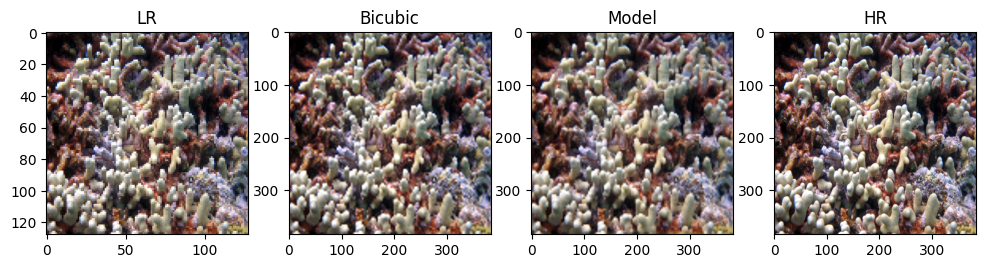

In [12]:
def bicubic_upscale(img):
    return tf.image.resize(img, [img.shape[1]*3, img.shape[2]*3], method="bicubic")

def compare(model, dataset):
    for lr, hr in dataset.take(1):
        pred = model.predict(lr)
        bicubic = bicubic_upscale(lr)

        plt.figure(figsize=(12,4))

        plt.subplot(1,4,1)
        plt.title("LR")
        plt.imshow(lr[0])

        plt.subplot(1,4,2)
        plt.title("Bicubic")
        plt.imshow(bicubic[0])

        plt.subplot(1,4,3)
        plt.title("Model")
        plt.imshow(pred[0])

        plt.subplot(1,4,4)
        plt.title("HR")
        plt.imshow(hr[0])

        plt.show()

compare(model, dataset)

Графики обучения

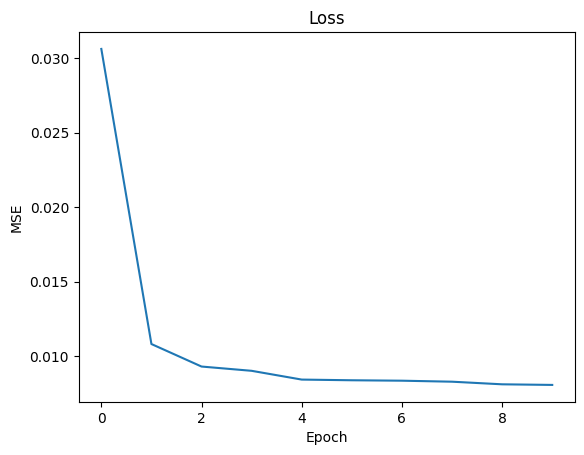

In [13]:
plt.plot(history.history['loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

**Demo**

Демонстрация включает:

исходное LR изображение, bicubi, результат модели, оригинал

cv2 upscale

In [14]:
def cv2_upscale(img):
    img = img.numpy()
    upscaled = []

    for i in range(len(img)):
        h, w = img[i].shape[:2]
        up = cv2.resize(img[i], (w*3, h*3), interpolation=cv2.INTER_CUBIC)
        upscaled.append(up)

    return np.array(upscaled)

Cравнение

In [20]:
def evaluate_all(model, dataset):
    model_psnr = []
    model_ssim = []

    cv2_psnr = []
    cv2_ssim = []

    for lr, hr in dataset.take(10):
        pred = model.predict(lr)
        bicubic = cv2_upscale(lr)

        for i in range(len(pred)):
            p = np.clip(pred[i], 0, 1)
            h = hr[i].numpy()
            b = np.clip(bicubic[i], 0, 1)

            model_psnr.append(psnr(h, p))
            model_ssim.append(ssim(h, p, channel_axis=2, data_range=1.0))

            cv2_psnr.append(psnr(h, b))
            cv2_ssim.append(ssim(h, b, channel_axis=2, data_range=1.0))

    print("=== MODEL ===")
    print(np.mean(model_psnr), np.mean(model_ssim))

    print("=== CV2 ===")
    print(np.mean(cv2_psnr), np.mean(cv2_ssim))

    return model_psnr, model_ssim, cv2_psnr, cv2_ssim

In [24]:
model_psnr, model_ssim, cv2_psnr, cv2_ssim = evaluate_all(model, dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 753ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 837ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
=== MODEL ===
22.351630135821416 0.66785926
=== CV2 ===
22.359614446981006 0.69599044


График сравнения

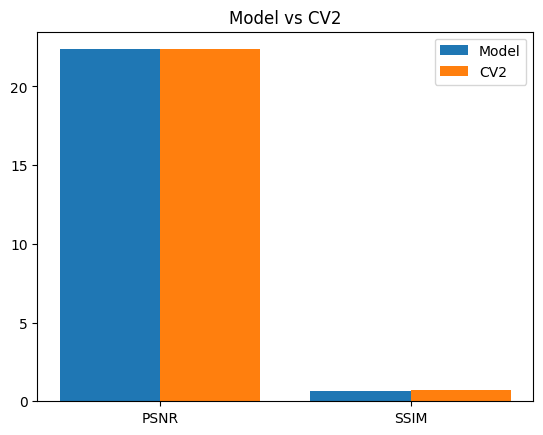

In [25]:
labels = ['PSNR', 'SSIM']

model_scores = [np.mean(model_psnr), np.mean(model_ssim)]
cv2_scores = [np.mean(cv2_psnr), np.mean(cv2_ssim)]

x = np.arange(len(labels))

plt.bar(x - 0.2, model_scores, 0.4, label='Model')
plt.bar(x + 0.2, cv2_scores, 0.4, label='CV2')

plt.xticks(x, labels)
plt.legend()
plt.title("Model vs CV2")
plt.show()

**Results**

В ходе экспериментов было проведено сравнение предложенной модели с классическим методом масштабирования изображений (bicubic interpolation, реализованным через OpenCV).

Полученные результаты показали, что при ограниченном количестве эпох обучения модель демонстрирует сопоставимое качество с bicubic интерполяцией:

PSNR: практически одинаковые значения,
SSIM: незначительное преимущество у bicubic

Это объясняется следующими факторами:

недостаточное время обучения модели, ограниченный размер обучающей выборки,
использование простой архитектуры ESPCN

Таким образом, результаты подтверждают, что при базовой настройке нейросетевая модель не всегда превосходит классические методы, однако имеет потенциал для улучшения при более глубоком обучении.

**Conclusions**

Плюсы:

высокая скорость, простота

Минусы:

потеря мелких деталей, не идеальная текстура

Будущая работа:

SRGAN, diffusion модели, perceptual loss